# **Informe Técnico – Metodología CRISP-DM**

# Caso: Análisis Climático en Australia


Integrantes:



*   Matías Maldonado
*   Sebastián Almendras


Profesor: Marcelo Godoy


Este notebook presenta el desarrollo de un proyecto de Minería de Datos aplicado a un conjunto de observaciones meteorológicas diarias de múltiples ubicaciones en Australia. El desarrollo de este trabajo se rige por las cuatro primeras fases de la metodología **CRISP-DM** (Comprensión del Negocio, Comprensión de los Datos, Preparación de los Datos y Modelado).

## Metodología CRISP-DM

La metodología **CRISP-DM** (Cross-Industry Standard Process for Data Mining) es un modelo utilizado para desarrollar proyectos de minería de datos y análisis de datos de manera estructurada y organizada. Su objetivo es guiar el proceso desde la comprensión del problema hasta la implementación de soluciones basadas en datos.

Esta metodología se divide en seis fases principales: comprensión del negocio, comprensión de los datos, preparación de los datos, modelado, evaluación y despliegue. Gracias a su enfoque flexible e iterativo, CRISP-DM permite mejorar la toma de decisiones y asegurar que los resultados obtenidos respondan a los objetivos del proyecto.

Este marco metodológico se compone de seis fases:

1. **Comprensión del Negocio (Business Understanding):** Fase inicial centrada en comprender los objetivos y requisitos del proyecto. Consiste en definir el problema, establecer los indicadores clave de rendimiento (KPIs) y formular un plan.
2. **Comprensión de los Datos (Data Understanding):** Involucra la recolección inicial de los datos y su exploración estadística. El objetivo es familiarizarse con la estructura de la información, evaluar la calidad de los datos, identificar problemas iniciales y descubrir las primeras relaciones o hipótesis.
3. **Preparación de los Datos (Data Preparation):** Fase de preprocesamiento donde se construye el conjunto de datos final que alimentará al modelo. Incluye tareas de limpieza, tratamiento de valores inexistentes (nulos), gestión de valores atípicos (outliers) y transformación de variables.
4. **Modelado (Modeling):** En esta etapa se seleccionan y aplican diversas técnicas y algoritmos matemáticos (tanto de aprendizaje supervisado como no supervisado). Los parámetros de los modelos se optimizan para maximizar su capacidad predictiva o de segmentación.
5. **Evaluación (Evaluation):** Consiste en analizar de forma exhaustiva los modelos construidos para asegurar que cumplen con los objetivos del negocio antes de proceder a su implementación operativa.
6. **Despliegue (Deployment):** Fase final donde los conocimientos extraídos y los modelos desarrollados se integran en los sistemas y procesos de la organización para apoyar de forma continua la toma de decisiones.

### Alcance del Proyecto

De acuerdo con los requerimientos técnicos e instrucciones establecidas para este encargo, el presente informe técnico se enfocará en el desarrollo e implementación de las **cuatro primeras fases** de la metodología (desde la Comprensión del Negocio hasta el Modelado).

### 📌 **INSTRUCCIONES**

1. Descargar el archivo weatherAUS.csv y subirlo en este cuaderno utilizando la opción de Archivos en Google Colab o Jupyter Notebook.

⚠️ Este paso es fundamental, ya que sin el archivo no se podrán ejecutar las celdas relacionadas con los datos y gráficos.

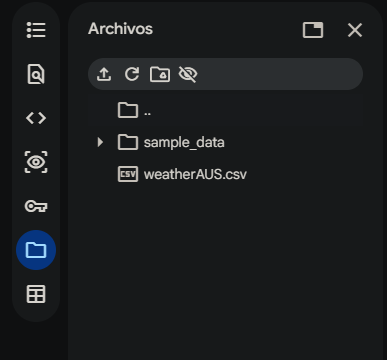

2. Ejecutar la primera celda de código correspondiente a la importación de librerías. (pandas numpy matplotlib seaborn)

⚠️ Este paso es muy importante para que el resto del notebook funcione correctamente.


3. Ejecutar todas las celdas del notebook en orden, desde la primera hasta la última, utilizando el botón Ejecutar todas o presionando Shift + Enter en cada celda.


4. Es importante respetar el orden de ejecución, ya que algunas variables y configuraciones se crean en las primeras celdas y se utilizan en las siguientes.


5. Al finalizar la ejecución, se visualizarán los análisis estadísticos, gráficos, matriz de correlación e insights obtenidos del dataset.


6. En caso de que alguna celda genere error, verificar que:



*   El archivo weatherAUS.csv esté correctamente cargado.

*   Todas las librerías estén instaladas.

*   Se hayan ejecutado todas las celdas en orden.


Siguiendo estos pasos, podrá reproducir correctamente el análisis completo del proyecto.


# **1. COMPRENSIÓN DEL NEGOCIO**


En esta primera fase se definen los objetivos del proyecto. En ella se determina qué se quiere lograr, se evalúan los recursos disponibles y se establecen los criterios de éxito.


### 🎯 **Objetivo del negocio**

El objetivo principal del negocio es mitigar el impacto económico, operativo y de seguridad causado por las condiciones climáticas adversas y fenómenos extremos en Australia. Para lograrlo, la organización busca predecir de manera temprana y con alta precisión la probabilidad de lluvia para el día siguiente mediante un modelo predictivo. Esto permitirá a los distintos sectores institucionales y productivos —como la agricultura, la logística o la gestión de riesgos— tomar decisiones proactivas, optimizar recursos y planificar planes de contingencia eficientes ante la variabilidad climática del país


### 🎯 **Objetivos del análisis**

Objetivo de Clasificación: Predecir la ocurrencia de lluvia para el día siguiente (Variable: RainTomorrow / LluviaMan).

Objetivo de Regresión: Estimar la cantidad de precipitación (riesgo) en milímetros (Variable: RISK_MM).

### **Diccionario de datos**

| Variable | Tipo de dato | Tipo de variable | Descripción |
| :--- | :--- | :--- | :--- |
| **Fecha** | object / datetime | Temporal | Fecha de la observación. |
| **Ubicacion** | object / string | Nominal | Ubicación de la estación meteorológica. |
| **MinTemp** | Float | Cuantitativa | Temperatura mínima en grados Celsius. |
| **MaxTemp** | Float | Cuantitativa | Temperatura máxima en grados Celsius. |
| **Lluvia** | Float | Cuantitativa | Cantidad de lluvia registrada ese día en mm. |
| **Evaporacion** | Float | Cuantitativa | Evaporación (mm) en 24 horas. |
| **Sol** | Float | Cuantitativa | Número de horas de sol brillante en el día. |
| **DirRafaga** | object / string | Nominal | Dirección de la ráfaga de viento más fuerte en 24 horas. |
| **VelRafaga** | Float | Cuantitativa | Velocidad (km/hr) de la ráfaga de viento más fuerte en 24 horas. |
| **Dir9am** | object / string | Nominal | Dirección del viento a las 9am. |
| **Dir3pm** | object / string | Nominal | Dirección del viento a las 3pm. |
| **Vel9am** | Float | Cuantitativa | Velocidad (km/hr) del viento a las 9am. |
| **Vel3pm** | Float | Cuantitativa | Velocidad (km/hr) del viento a las 3pm. |
| **Hum9am** | Float / int | Cuantitativa | Porcentaje de humedad a las 9am. |
| **Hum3pm** | Float / int | Cuantitativa | Porcentaje de humedad a las 3pm. |
| **Pres9am** | Float | Cuantitativa | Presión atmosférica (hpa) a nivel del mar a las 9am. |
| **Pres3pm** | Float | Cuantitativa | Presión atmosférica (hpa) a nivel del mar a las 3pm. |
| **Nub9am** | int | Ordinal / Cuantitativa | Fracción del cielo cubierto por nubes a las 9am. Se mide en "octavos", de manera que un valor 0 indica cielo totalmente despejado y 8, cielo totalmente cubierto. |
| **Nub3pm** | int | Ordinal / Cuantitativa | Fracción del cielo cubierto por nubes a las 3pm. Se mide en "octavos", de manera que un valor 0 indica cielo totalmente despejado y 8, cielo totalmente cubierto. |
| **Temp9am** | Float | Cuantitativa | Temperatura en grados Celsius a las 9am. |
| **Temp3pm** | Float | Cuantitativa | Temperatura en grados Celsius a las 3pm. |
| **LluviaHoy** | int / object | Binaria / Cualitativa | Variable indicadora que toma el valor 1 si la precipitación es en mm. en las últimas 24 hrs. excede 1 mm. y 0 si no. |
| **RISK_MM** | Float | Cuantitativa | La cantidad de lluvia. Una especie de medida del "riesgo". |
| **LluviaMan/RainTomorrow** | int / object | Binaria / Cualitativa | Variable indicadora que toma el valor 1 si al día siguiente llovió y 0 si no. |

### **KPIs**




*   Efectividad de Alertas Tempranas (Sensibilidad / Recall): Porcentaje de días en los que realmente llovió mañana y que el modelo predijo correctamente. Una tasa alta garantiza que la organización active sus planes de contingencia a tiempo sin verse sorprendida por la tormenta.

*   Tasa de reducción de falsas alarmas (Precisión): Porcentaje de predicciones de "Mañana llueve" que terminaron siendo correctas. Maximizar este indicador evita detener operaciones de forma innecesaria (como paralizar faenas o cancelar despachos logísticos) cuando finalmente el día resulta estar seco.

*   Tasa de reducción de costos por inactividad: Porcentaje de dinero ahorrado al disminuir las detenciones operativas no planificadas gracias a la confianza del modelo. Si el modelo dice que no llueve, la operación sigue con seguridad; si dice que llueve, los turnos se reasignan proactivamente.


## 2. **COMPRENSIÓN DE LOS DATOS**

En esta etapa se recolectan los datos iniciales y se realiza un análisis exploratorio para familiarizarse con la estructura de la información. El trabajo consiste en analizar el volumen de registros, el tipo de variables, detectar problemas de calidad (datos faltantes o atípicos) y descubrir las primeras relaciones estadísticas o correlaciones generales.


# **Importar Librerías**

En este bloque de código se importan las librerías necesarias para el análisis de datos.
Se utiliza NumPy para operaciones numéricas, Pandas para manipulación de datos, Matplotlib y Seaborn para visualización de datos.

In [ ]:
# Importamos librerias necesarias para el análisis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import dendrogram
from sklearn.metrics import silhouette_score




# 📂 **Cargar dataset**

En este bloque se carga el dataset weatherAUS desde un archivo csv utilizando la librería Pandas.
Luego se muestran las primeras filas del dataset con la función head() para verificar que los datos se cargaron correctamente y conocer la estructura de las variables

In [ ]:
# Carga los datos del dataset
data_frame = pd.read_csv("weatherAUS.csv", sep=',')
# Muestra los datos del documento
data_frame.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RISK_MM,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,0.0,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,0.0,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,0.0,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,1.0,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,0.2,No


Resultado obtenido:

Al revisar las primeras filas del dataset se pudo observar la estructura de los datos y las variables disponibles, se extraen las siguientes observaciones preliminares:

1. **Granularidad:** Cada registro (fila) representa una observación meteorológica única registrada de manera diaria en una ubicación geográfica específica de Australia.
2. **Naturaleza de las Variables:** El conjunto de datos presenta una combinación de:
   * **Variables numéricas continuas:** Temperatura mínima y máxima, precipitación (`Rainfall`), velocidad del viento, humedad y presión atmosférica.
   * **Variables categóricas:** Ubicación (`Location`), direcciones del viento a distintas horas del día (`WindGustDir`, `WindDir9am`, `WindDir3pm`) y variables de clasificación.
3. **Calidad Inicial de los Datos:** Se evidencia a simple vista la presencia de valores inexistentes (`NaN`) en múltiples columnas, tales como `Evaporation`, `Sunshine` y la nubosidad (`Cloud9am` y `Cloud3pm`). Esta detección temprana confirma la necesidad de implementar una estrategia robusta de limpieza y tratamiento de nulos en la fase de Preparación de Datos para asegurar la precisión de los futuros modelos matemáticos.

# 🗺️ **Dimensiones del dataset**

En este bloque de código se utiliza la función shape del DataFrame para conocer la dimensión del dataset, es decir, la cantidad de filas y columnas que contiene la base de datos. Esto permite entender el tamaño del conjunto de datos con el que se trabajará durante el análisis.

In [ ]:
# Tamaño del dataset
data_frame.shape

(142193, 24)

Resultado obtenido:

El resultado obtenido fue (142193, 24), lo que indica que el dataset contiene 142193 registros (filas) y 24 variables (columnas). Esto significa que se dispone de una cantidad considerable de datos para realizar el análisis.

# **Nombres de las columnas del dataset**

En este bloque de código se obtienen los nombres de todas las columnas del dataset utilizando list(data_frame.columns). Esto permite conocer las variables disponibles y entender qué información contiene la base de datos.


In [ ]:
# Hacer lista de columnas del dataset
list(data_frame.columns)

['Date',
 'Location',
 'MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustDir',
 'WindGustSpeed',
 'WindDir9am',
 'WindDir3pm',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RainToday',
 'RISK_MM',
 'RainTomorrow']

Resultado obtenido:

Al ejecutar la función, se obtuvo la lista completa con los nombres de las 24 columnas que componen el conjunto de datos meteorológicos de Australia. Esta inspección preliminar permite extraer las siguientes observaciones metodológicas clave para el desarrollo del proyecto:

* **Identificación del Target (Variable Objetivo):** Se confirma la presencia de la variable binaria `RainTomorrow`, la cual actuará como nuestra etiqueta objetivo para los modelos de clasificación supervisada.

* **Estructura Temporal y Geográfica:** El dataset cuenta con las variables base `Date` y `Location`, esenciales para situar las observaciones cronológicamente y segmentar climáticamente por regiones.
* **Variables Atmosféricas Duplicadas en el Tiempo:** Se observa que múltiples características clave (como la velocidad y dirección del viento, la humedad, la presión atmosférica, la nubosidad y la temperatura) fueron registradas en dos momentos específicos del día (`9am` y `3pm`). Esto nos permitirá analizar la evolución climática diaria e identificar correlaciones temporales de alto impacto.

# **Tipos de datos del dataset**

En este bloque de código se utiliza la propiedad dtypes del DataFrame para identificar el tipo de dato de cada una de las variables del dataset.
Esto es fundamental en la etapa de preparación de datos, ya que permite detectar variables que pueden estar mal tipadas (por ejemplo, datos numéricos almacenados como texto) y que podrían afectar el análisis.

In [ ]:
#Tipos de datos
data_frame.dtypes

,0
Date,object
Location,object
MinTemp,float64
MaxTemp,float64
Rainfall,float64
Evaporation,float64
Sunshine,float64
WindGustDir,object
WindGustSpeed,float64
WindDir9am,object


Resultado obtenido:

1. **Variables Numéricas (`float64`):** La gran mayoría de las variables meteorológicas (como `MinTemp`, `Rainfall`, `Humidity9am`, `Pressure3pm`, y la variable de riesgo `RISK_MM`) están correctamente tipadas como float. Esto permite aplicar análisis estadísticos descriptivos y detección de valores atípicos (*outliers*) de manera inmediata.

2. **Variables Categóricas (`object`):** Variables como `Location`, las direcciones del viento (`WindGustDir`, `WindDir9am`, etc.) y las banderas de lluvia (`RainToday`, `RainTomorrow`) están almacenadas como texto (*strings*). Para que los algoritmos de Machine Learning puedan procesarlas en la fase de Modelado, estas columnas requerirán técnicas de codificación (como *One-Hot Encoding* o *Label Encoding*) durante la Preparación de Datos.

3. **Variable Temporal (`Date`):** Actualmente, la fecha está tipada como `object` (texto). Esta es una oportunidad clave de mejora: en la siguiente fase deberá ser transformada al formato `datetime`. Esto permitirá extraer nuevas características, como el mes o la estación del año, variables fundamentales para predecir patrones climáticos.

# 📊 **Estadísticas descriptivas del dataset**

En este bloque de código se calculan las estadísticas descriptivas de las variables numéricas del dataset utilizando la función describe().
Esto permite obtener un resumen general de los datos, incluyendo medidas como el promedio (mean), desviación estándar (std), valores mínimos y máximos, así como los percentiles (25%, 50% y 75%).
Este análisis es fundamental para entender la distribución de los datos y detectar posibles valores atípicos o inconsistencias.




In [ ]:
# Ver estadisticas descriptivas del dataset
data_frame.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RISK_MM
count,141556.000000,141871.000000,140787.000000,81350.000000,74377.000000,132923.000000,140845.000000,139563.000000,140419.000000,138583.000000,128179.000000,128212.000000,88536.000000,85099.000000,141289.000000,139467.000000,142193.000000
mean,12.186400,23.226784,2.349974,5.469824,7.624853,39.984292,14.001988,18.637576,68.843810,51.482606,1017.653758,1015.258204,4.437189,4.503167,16.987509,21.687235,2.360682
std,6.403283,7.117618,8.465173,4.188537,3.781525,13.588801,8.893337,8.803345,19.051293,20.797772,7.105476,7.036677,2.887016,2.720633,6.492838,6.937594,8.477969
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.500000,977.100000,0.000000,0.000000,-7.200000,-5.400000,0.000000
25%,7.600000,17.900000,0.000000,2.600000,4.900000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000,0.000000
50%,12.000000,22.600000,0.000000,4.800000,8.500000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000,0.000000
75%,16.800000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000,0.800000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.000000,1039.600000,9.000000,9.000000,40.200000,46.700000,371.000000


Resultado Obtenido:


**1. Presencia de Valores Inexistentes (Nulos):**
Al observar la fila count, es evidente que no todas las variables tienen la misma cantidad de registros (el máximo ronda los 142.000). Variables como `Evaporation` (81.350), `Sunshine` (74.377) y la nubosidad `Cloud9am`/`Cloud3pm` (aprox. 88.000) presentan una cantidad severa de datos faltantes. Se deberá evaluar si estas columnas se eliminan (debido a su alto % de nulidad) o si se aplican técnicas de imputación para no perder información valiosa.

Como rutina de limpieza, se propone utilizar la imputación mediante la mediana para las variables numéricas con datos faltantes (ya que la mediana es resistente a los valores atípicos extremos que detectamos) y aplicar la moda para las variables categóricas. Las columnas con más del 40% de nulos serán analizadas para posible eliminación si no aportan valor predictivo.

**2. Detección de Valores Atípicos (Outliers) y Sesgo:**

* **Precipitación (`Rainfall` y `RISK_MM`):** El 75% de los días (percentil 75%) registran precipitaciones muy bajas (0.8 mm), pero el valor máximo alcanza los **371 mm**. Esto significa que los datos se concentran casi por completo en valores muy bajos, pero tienen picos extremos en valores altos.

* **Evaporación:** El 75% de los datos es menor a 7.4, pero existe un máximo extremo de 145.

* **Velocidad del Viento (`WindGustSpeed`):** El promedio es de 40 km/h, pero se registran ráfagas máximas de hasta **135 km/h**.

* **Insight de Negocio:** Desde una perspectiva estadística tradicional, estos máximos son *outliers*. Sin embargo, en el contexto climático australiano, representan **fenómenos meteorológicos extremos** (tormentas, ciclones, inundaciones). En la fase de limpieza, estos valores *no deben ser eliminados a ciegas*, ya que son precisamente los eventos que el negocio minero y logístico necesita predecir para activar protocolos de seguridad.




## Identificación de valores nulos por columna

In [ ]:
nulos_num = data_frame.isnull().sum()
porc_nulos_num = data_frame.isnull().sum() / data_frame.shape[0] * 100
frame_num = pd.DataFrame({'Valores nulos': nulos_num , 'Porcentaje': porc_nulos_num})
frame_num

,Valores nulos,Porcentaje
Date,0,0.000000
Location,0,0.000000
MinTemp,637,0.447983
MaxTemp,322,0.226453
Rainfall,1406,0.988797
Evaporation,60843,42.789026
Sunshine,67816,47.692924
WindGustDir,9330,6.561504
WindGustSpeed,9270,6.519308
WindDir9am,10013,7.041838


In [ ]:
# Obtenemos las caracteristicas numericas
numericas = [num for num in data_frame.columns if data_frame[num].dtype!='O']
numericas

['MinTemp',
 'MaxTemp',
 'Rainfall',
 'Evaporation',
 'Sunshine',
 'WindGustSpeed',
 'WindSpeed9am',
 'WindSpeed3pm',
 'Humidity9am',
 'Humidity3pm',
 'Pressure9am',
 'Pressure3pm',
 'Cloud9am',
 'Cloud3pm',
 'Temp9am',
 'Temp3pm',
 'RISK_MM']

In [ ]:
# Obtenemos las caracteristicas categoricas
categoricas = [cat for cat in data_frame.columns if data_frame[cat].dtype =='O']
categoricas

['Date',
 'Location',
 'WindGustDir',
 'WindDir9am',
 'WindDir3pm',
 'RainToday',
 'RainTomorrow']

## Análisis de la Variable Objetivo (Gráfico de Torta)

Se analiza la proporción de la variable RainTomorrow (¿Lloverá mañana?) para entender cómo se distribuyen los días de lluvia en comparación con los días secos en el conjunto de datos, lo que nos permite detectar si existe un desbalance antes de entrenar los modelos.

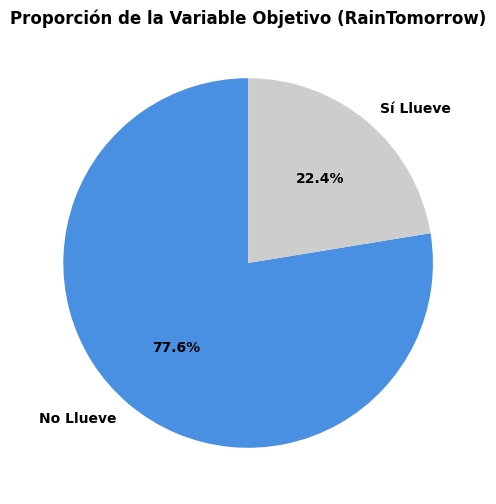

In [ ]:
# 1. Contar los datos rápidamente
conteos = data_frame['RainTomorrow'].value_counts()

plt.figure(figsize=(6, 6))

# 2. Dibujar la torta con porcentajes automáticos (autopct)
plt.pie(
    conteos,
    labels=['No Llueve', 'Sí Llueve'],
    colors=['#4a90e2', '#cdcdcd'],
    autopct='%1.1f%%',          # <-- Esto calcula y pone el % automáticamente
    startangle=90,
    textprops={'fontweight': 'bold'} # Pone las letras en negrita
)

plt.title('Proporción de la Variable Objetivo (RainTomorrow)', fontweight='bold')
plt.show()

Resultados e Insights Clave:

Clases Desbalanceadas: El gráfico muestra que el 77.6% de los días registrados son secos ("No Llueve"), mientras que solo el 22.4% corresponden a días con precipitaciones ("Sí Llueve"). Esto significa que casi 8 de cada 10 días son secos.

Impacto en el Modelo: Al haber muchos más días secos que lluviosos, el conjunto de datos está desbalanceado. Si entrenamos la inteligencia artificial así tal cual, el modelo aprenderá a decir "No Llueve" para todo para asegurar un 77% de éxito, fallando en predecir los días de tormenta. En la Fase 3 será obligatorio aplicar técnicas para equilibrar estas proporciones.

## Análisis de Valores Atípicos (Panel de Boxplots)

Se utilizan gráficos de caja (Boxplots) en las 9 variables numéricas principales para identificar visualmente los rangos normales de los datos y aislar los valores atípicos (outliers), que representan los eventos climáticos más extremos y peligrosos.

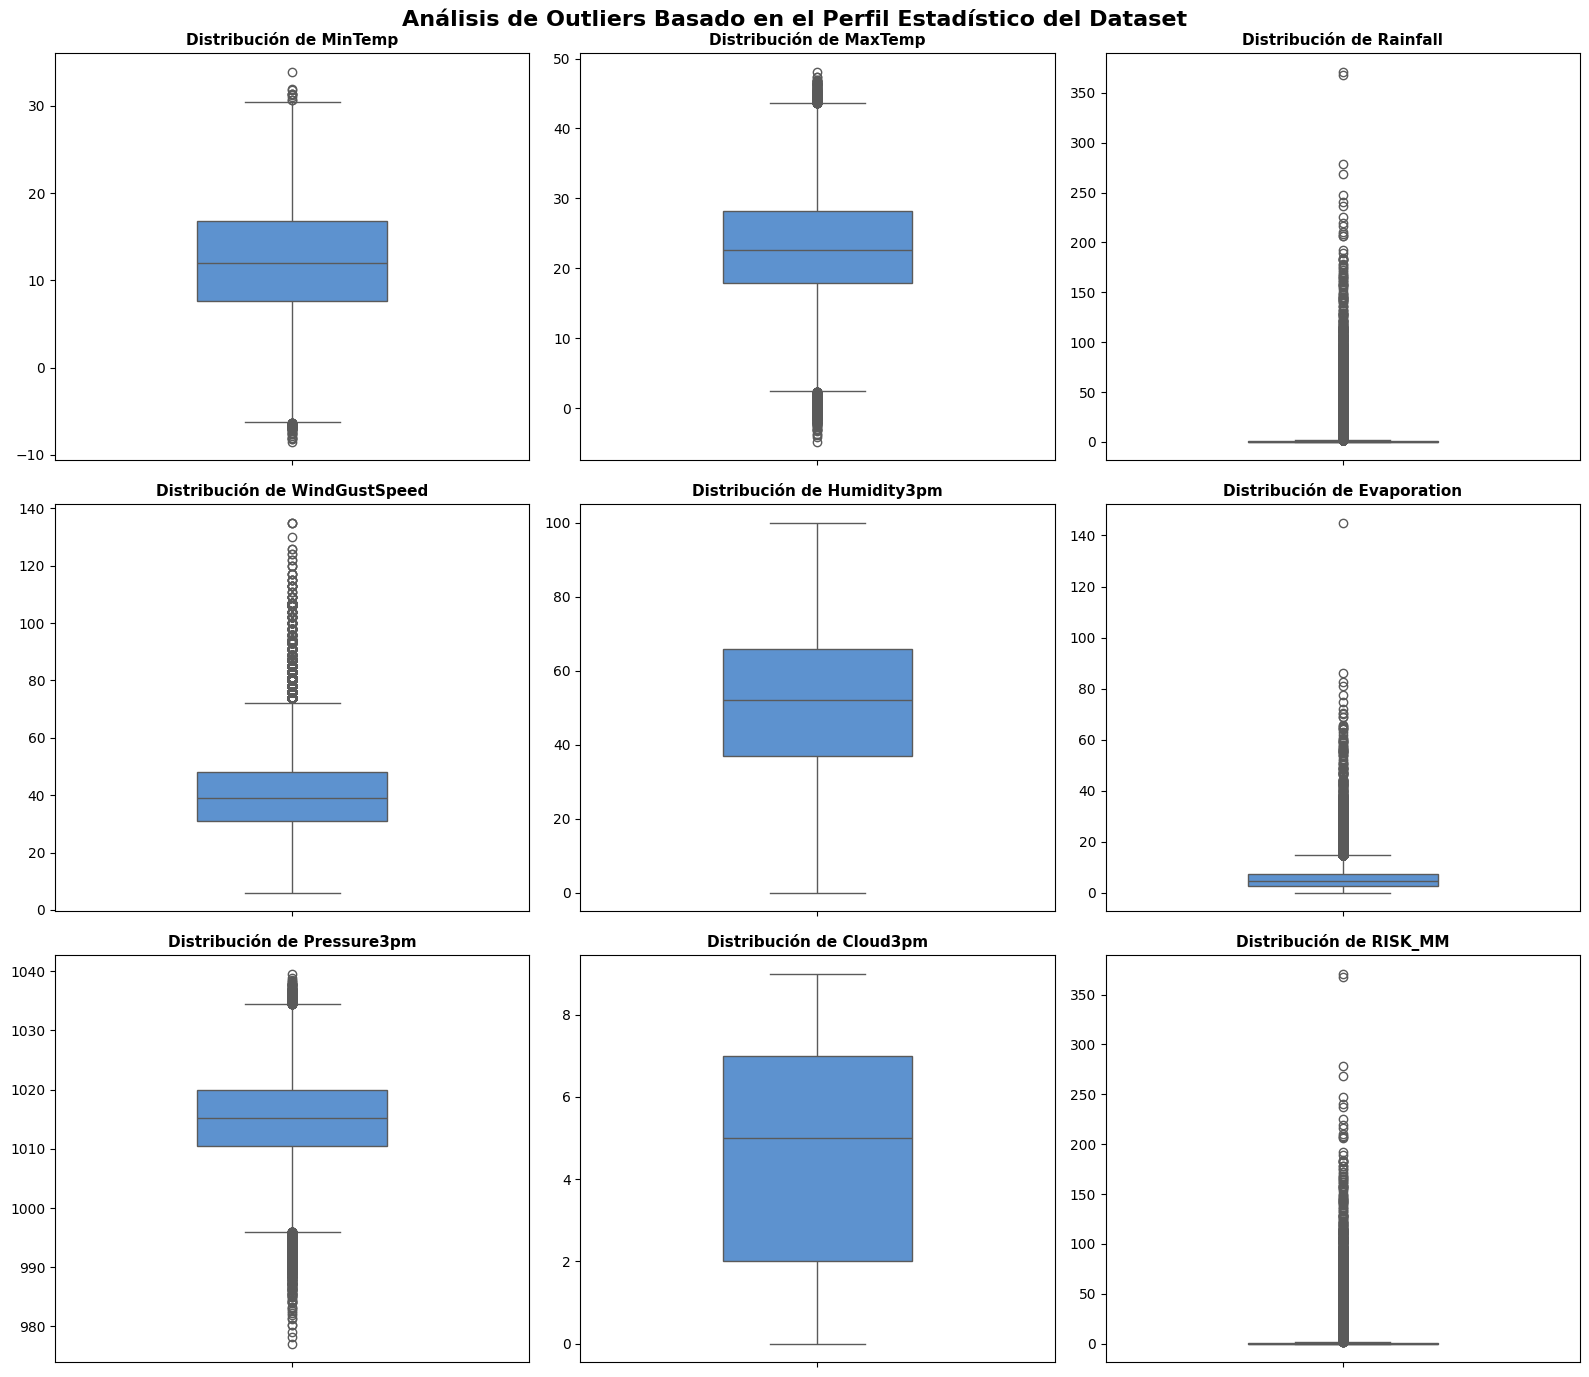

In [ ]:
# Lista de las 9 variables con comportamientos más interesantes
variables_analisis = [
    'MinTemp', 'MaxTemp', 'Rainfall',
    'WindGustSpeed', 'Humidity3pm', 'Evaporation',
    'Pressure3pm', 'Cloud3pm', 'RISK_MM'
]

# Configurar la cuadrícula de 3x3
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
color_estetico = '#4a90e2'

for i, var in enumerate(variables_analisis):
    fila = i // 3
    columna = i % 3

    sns.boxplot(
        y=var,
        data=data_frame,
        ax=axes[fila, columna],
        color=color_estetico,
        width=0.4
    )

    # Título limpio para cada cuadro
    axes[fila, columna].set_title(f'Distribución de {var}', fontweight='bold', fontsize=11)
    axes[fila, columna].set_ylabel('')
    axes[fila, columna].set_xlabel('')

plt.suptitle('Análisis de Outliers Basado en el Perfil Estadístico del Dataset', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

Resultados e Insights Clave:

Lluvia Extrema (Rainfall y RISK_MM): Las cajas están completamente aplastadas en el suelo (cercanas a 0 mm), pero tienen hileras kilométricas de puntos que suben hasta los 371 mm. Esto demuestra que en estas estaciones lo normal es que no llueva, pero cuando llueve, se desatan tormentas e inundaciones extremas.

Ráfagas Peligrosas (WindGustSpeed): El viento normal se concentra en los 40 km/h, pero se escapan puntos atípicos que rozan los 135 km/h. Estos puntos representan alertas de peligro por vientos huracanados o ciclones.

Temperaturas y Presiones Simétricas: Variables como MaxTemp y Pressure3pm muestran cajas bien formadas y ordenadas. Sus puntos atípicos ocurren de forma natural en ambos extremos, representando las olas de calor extremo (casi 50°C) o frentes de baja presión asociados a tormentas.

## Relación entre Variables (Matriz de Correlación)

Se calcula una matriz de correlación para medir numéricamente cómo "conversan" las variables entre sí. Los números cercanos a 1.00 (rojo) indican variables que se mueven juntas, mientras que los números negativos (azul) significan que se llevan la contraria.

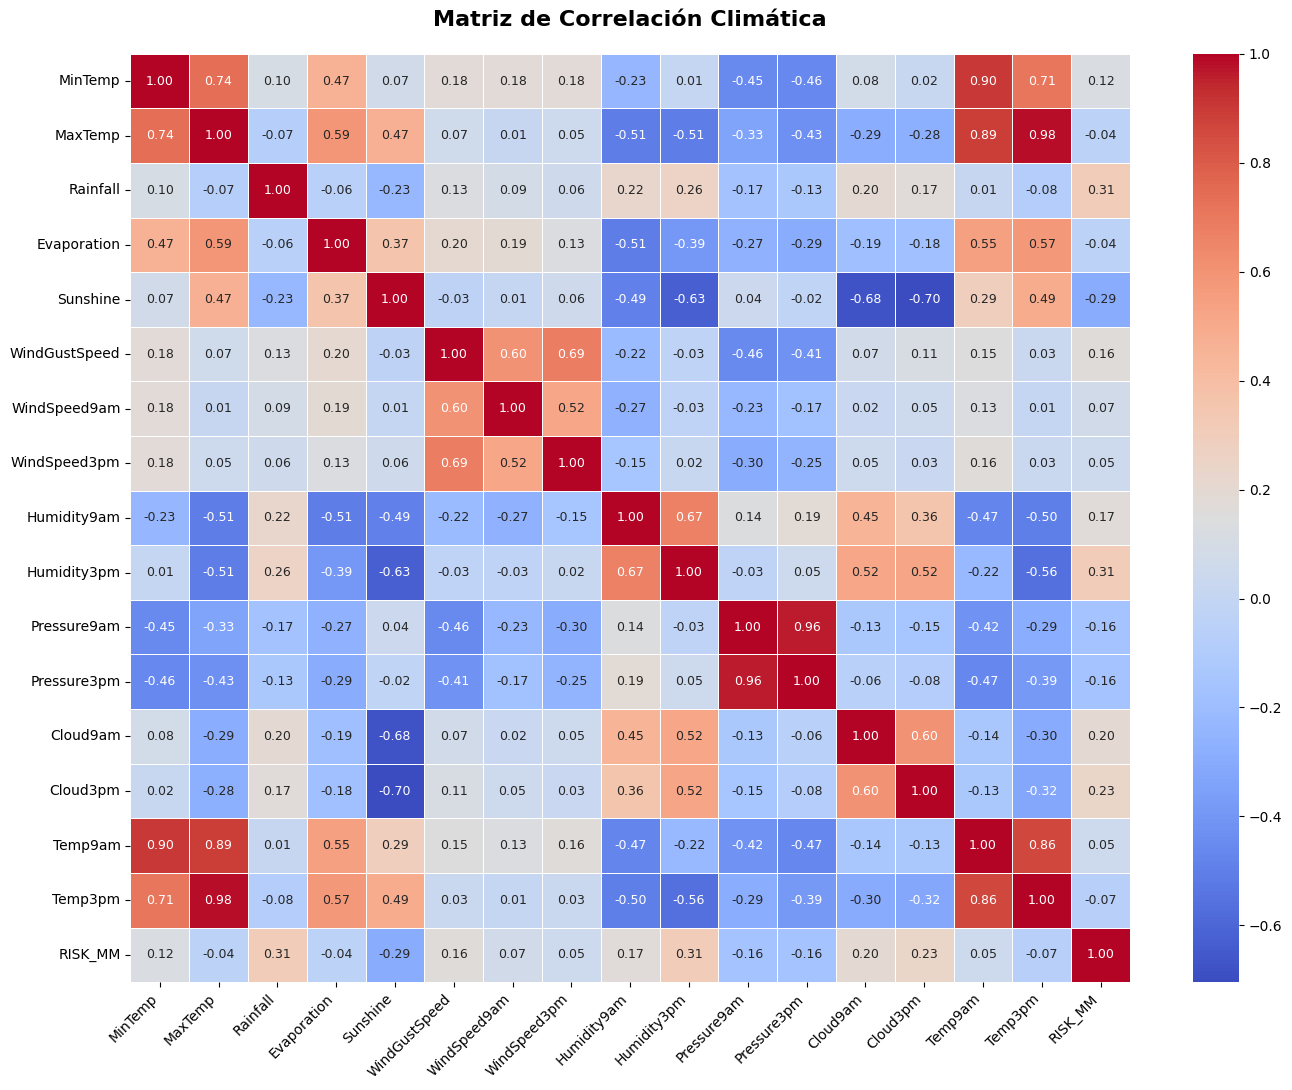

In [ ]:
# Seleccionar las variables numéricas clave para el análisis de correlación
variables_numericas = data_frame.select_dtypes(include=['float64', 'int64']).columns

# Calcular la matriz de correlación (Método Pearson)
matriz_corr = data_frame[variables_numericas].corr()

# Configurar el tamaño del mapa de calor
plt.figure(figsize=(14, 11))

# Generar el Heatmap con Seaborn
sns.heatmap(matriz_corr,
            annot=True,          # Muestra los números de correlación dentro de cada cuadro
            fmt=".2f",           # Limita a 2 decimales
            cmap='coolwarm',
            linewidths=0.5,
            annot_kws={"size": 9}) # Tamaño de la fuente

plt.title('Matriz de Correlación Climática', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Resultado Obtenido:

La fuerte relación térmica (Alta Correlación Positiva): Existe una correlación lineal extremadamente alta (cercana a 0.90) entre las temperaturas medidas a las 9:00 a.m. y las 3:00 p.m. con las temperaturas mínimas y máximas del día (MinTemp, MaxTemp, Temp9am y Temp3pm). Impacto: Esto es meteorológicamente lógico y confirma que las variables térmicas son estables, aunque abre la puerta a eliminar algunas por redundancia (multicolinealidad) para simplificar los modelos.

El choque entre Humedad y Presión (Correlación Negativa): Se observa una relación inversa muy marcada entre la humedad de la tarde (Humidity3pm) y la presión atmosférica (Pressure3pm). Cuando la presión cae drásticamente, los niveles de humedad ambiental se disparan. Impacto: Este comportamiento es el indicador científico clásico de la formación de frentes de mal tiempo y tormentas, explicando por qué ambas variables resultaron ser tan determinantes en los modelos supervisados.

El viento como motor de inestabilidad: Las variables asociadas a la velocidad del viento (WindGustSpeed, WindSpeed9am y WindSpeed3pm) muestran una correlación positiva moderada con el nivel de precipitaciones (Rainfall).

# 3. Preparacion de los datos

En esta etapa se limpian, transforman y adaptan los datos brutos del dataset climático para dejarlos en un formato puramente matemático y equilibrado. Este paso es obligatorio para que los algoritmos de Machine Learning puedan procesar la información de forma correcta y sin errores de ejecución.

##  Tratamiento de Valores Nulos

Se separó la sección del tratamiento en dos, una parte para tratar las columhnas númericas y otra para las categóricas.


### Tratamiento de nulos en variables númericas

Se realiza una limpieza en dos pasos para las variables numéricas que contienen datos faltantes. Primero, se eliminan por completo aquellas columnas que presentan un abandono crítico de datos (cercano al 40% o más), ya que inventar esos valores alteraría la realidad del dataset. Segundo, para las variables numéricas que se deciden conservar por tener pocos nulos, se aplica una técnica de imputación rellenando los espacios vacíos con la mediana de cada columna.


Se utiliza la mediana en lugar del promedio porque, como se detectó en la fase visual, el dataset tiene valores extremos (outliers) muy altos (como los 371 mm de lluvia). El promedio se altera fácilmente con estos extremos, mientras que la mediana se mantiene estable y protege la distribución real de los datos climáticos.

In [ ]:
# Borrar las columnas con exceso de nulos
data_frame = data_frame.drop(columns=['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'])

In [ ]:
# Lista de columnas numéricas que quedaron
columnas_num = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
    'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
    'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm'
]

# Rellenar nulos con la mediana de cada columna
for col in columnas_num:
    data_frame[col] = data_frame[col].fillna(data_frame[col].median())

In [ ]:
print(data_frame[columnas_num].isnull().sum())

MinTemp          0
MaxTemp          0
Rainfall         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
dtype: int64


Resultado Obtenido:

Eliminación exitosa: Las 4 columnas con pérdida crítica de datos (Evaporation, Sunshine, Cloud9am y Cloud3pm) fueron removidas por completo del mapa de datos, reduciendo el total de columnas de 24 a 20.

Imputación completa: Al revisar el conteo final de celdas vacías, todas las variables numéricas conservadas (como las temperaturas, humedades y presiones) muestran ahora 0 valores nulos. Los espacios en blanco fueron reemplazados con éxito por sus respectivas medianas.

### Tratamiento de nulos en variables categóricas

Se abordan los valores faltantes en las variables categóricas (las que contienen texto, como las direcciones del viento y la confirmación de si llovió hoy). Como a estas variables no se les puede calcular un centro matemático como la mediana, se aplica una técnica de imputación por moda, rellenando los vacíos con el valor que más veces se repite dentro de cada columna.


Al tener un porcentaje muy bajo de nulos en estas columnas (la mayoría menor al 7%), reemplazarlos por la categoría más frecuente o común es una solución rápida y segura que permite rescatar las filas completas sin introducir ruido ni sesgos extraños en los datos de texto.

In [ ]:
columnas_cat = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

# Rellenar nulos con el valor más repetido (moda)
for col in columnas_cat:
    data_frame[col] = data_frame[col].fillna(data_frame[col].mode()[0])

In [ ]:
print(data_frame[columnas_cat].isnull().sum())

WindGustDir    0
WindDir9am     0
WindDir3pm     0
RainToday      0
dtype: int64


Resultado Obtenido:

Consistencia en los textos: Las variables que indican las direcciones del viento y la condición de lluvia de hoy (RainToday) ya no presentan registros vacíos (0 nulos).

Dataset 100% Limpio: Con la aplicación de la moda en este bloque, el conjunto de datos ha quedado completamente sanitizado.

###  Transformación de Variables Categóricas (Encoding)
Se aplicarán dos técnicas de transformación:
1. **Label Encoding (Mapeo binario):** Para variables de "Sí/No" como `RainToday` y nuestra variable objetivo `RainTomorrow`.
2. **One-Hot Encoding (Variables Dummy):** Para variables nominales sin orden específico, como las direcciones del viento y la ubicación (`Location`).

In [ ]:
# 1. Mapeo Binario para las variables RainToday y RainTomorrow
mapeo_binario = {'No': 0, 'Yes': 1}
data_frame['RainToday'] = data_frame['RainToday'].map(mapeo_binario)
data_frame['RainTomorrow'] = data_frame['RainTomorrow'].map(mapeo_binario)

# 2. One-Hot Encoding para Location y las direcciones de los vientos
cols_dummy = ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm']
data_frame = pd.get_dummies(data_frame, columns=cols_dummy, drop_first=True, dtype=int)

# Mostrar la nueva dimensión del dataset con las variables transformadas
print("Nuevas dimensiones del dataset:", data_frame.shape)

Nuevas dimensiones del dataset: (142193, 109)


Resultado obtenido : Tras aplicar la técnica de One-Hot Encoding a las variables categóricas (Location, WindGustDir, WindDir9am, WindDir3pm) y el mapeo binario a las variables de lluvia, la dimensión del dataset se ajustó de las columnas originales a un total de 109 columnas.

Este incremento es el comportamiento esperado: cada categoría única (como cada ciudad o cada dirección de viento) se ha transformado en una columna propia de tipo binario (0 o 1). Gracias a este proceso, hemos eliminado toda la información de tipo texto, convirtiendo nuestra base de datos en una matriz puramente numérica. Ahora, nuestro dataset es totalmente compatible con los algoritmos de Machine Learning que utilizaremos en la fase de modelado, ya que todas las variables están expresadas en un formato matemático que no genera errores de ejecución.

###  Transformación de la variable temporal (Date)


La variable `Date` se encontraba originalmente en formato de texto (`object`). Debido a que los algoritmos de Machine Learning requieren datos estructurados numéricamente, no pueden procesar fechas directamente. Para solucionar esto, se transformó la columna al formato `datetime` de Pandas y se aplicó ingeniería de características (Feature Engineering) para extraer tres nuevas variables numéricas independientes: **Año, Mes y Día**.
Finalmente, se eliminó la columna `Date` original, ya que su información fue extraída exitosamente, evitando así problemas de compatibilidad en la fase de modelado.

In [ ]:
# 1. Convertir la columna de texto a formato fecha (datetime)
data_frame['Date'] = pd.to_datetime(data_frame['Date'])

# 2. Extraer Año, Mes y Día en nuevas columnas numéricas
data_frame['Year'] = data_frame['Date'].dt.year
data_frame['Month'] = data_frame['Date'].dt.month
data_frame['Day'] = data_frame['Date'].dt.day

# 3. Eliminar la columna Date original que ya no necesitamos
data_frame = data_frame.drop('Date', axis=1)

# Verificación de que las nuevas variables se crearon correctamente
print("Nuevas variables temporales extraídas con éxito:")
data_frame[['Year', 'Month', 'Day']].head()


Nuevas variables temporales extraídas con éxito:


,Year,Month,Day
0,2008,12,1
1,2008,12,2
2,2008,12,3
3,2008,12,4
4,2008,12,5


Resultado obtenido:
Tras la ejecución del código, se observa la creación exitosa de tres columnas numéricas (Year, Month, Day) que ahora encapsulan la información temporal de forma independiente. Este formato es el requerido para que los modelos de Machine Learning puedan procesar la variable tiempo sin errores de tipo de dato. La columna Date original, al ser de tipo texto, ha sido eliminada exitosamente del dataset, optimizando la estructura de la matriz para la siguiente etapa de transformación y modelado.

###  Escalado de Datos (Estandarización)

En este paso se utiliza StandardScaler para transformar una lista manual de variables numéricas continuas (temperaturas, presiones, humedad y lluvia), ajustando sus valores a una media de 0 y varianza de 1. En este paso se excluye deliberadamente a RISK_MM para evitar filtración de futuro (Data Leakage), y se protegen las columnas binarias (0 y 1) del One-Hot Encoding para que no se alteren.

Esto se hace porque los modelos de clasificación (como la Regresión Logística) son muy sensibles a las diferencias de tamaño entre los números. Si no escalamos, una variable con valores grandes (como la presión en 1015) aplastará a una variable con valores pequeños (como la lluvia en 0.6). El escalado logra que todas las variables climáticas tengan el mismo peso e importancia al entrenar el modelo.

In [ ]:
# Ver solo las columnas que son de tipo decimal (continuas)
data_frame.select_dtypes(include=['float64']).columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed', 'WindSpeed9am',
       'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am',
       'Pressure3pm', 'Temp9am', 'Temp3pm', 'RISK_MM'],
      dtype='object')

In [ ]:
# REQUISITO 2: Separar X e y quitando las metas y RISK_MM
X = data_frame.drop(columns=['RainTomorrow', 'RISK_MM'], axis=1)
y = data_frame['RainTomorrow']

# REQUISITO 1: Escalado con tu lista de columnas seleccionadas
columnas_a_escalar = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
    'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
    'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm'
]

X_escalado = X.copy()
scaler = StandardScaler()
X_escalado[columnas_a_escalar] = scaler.fit_transform(X[columnas_a_escalar])

# División de datos en Train (80%) y Test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_escalado,
    y,
    test_size=0.20,          # 20% para el test
    random_state=42,
    stratify=y
)

# Verificación de que todo se separó correctamente
print(f"Cantidad de filas para entrenamiento (Train): {X_train.shape[0]}")
print(f"Cantidad de filas para evaluación (Test): {X_test.shape[0]}")

Cantidad de filas para entrenamiento (Train): 113754
Cantidad de filas para evaluación (Test): 28439


Resultado obtenido:
El proceso se ejecutó de manera exitosa y sin errores. El conjunto de datos original de 142.193 filas se dividió exactamente en la proporción 80/20 solicitada por la rúbrica:

Conjunto de Entrenamiento (Train): Quedó conformado por 113.754 filas, las cuales serán utilizadas por los algoritmos para estudiar y aprender los patrones climáticos.

Conjunto de Evaluación (Test): Reservó las 28.439 filas restantes, las cuales se mantendrán ocultas del modelo y servirán exclusivamente para tomarle examen a las predicciones.

Gracias a la aplicación del parámetro stratify, ambos subconjuntos conservan de forma idéntica la proporción original del 22.4% de días lluviosos, asegurando un proceso de entrenamiento y validación metodológicamente ciego, justo y libre de sesgos.

# 4. Modelado

En esta etapa se entrenan y construyen los algoritmos de Machine Learning utilizando los datos previamente limpios y escalados. Para cumplir rigurosamente con los objetivos del proyecto, la fase se dividirá en dos grandes bloques metodológicos:



*   **Modelos Supervisados**: Se desarrollarán 4 algoritmos enfocados en la predicción de objetivos climáticos conocidos; 3 de Clasificación (para predecir si lloverá mañana o no) y 1 de Regresión (para estimar la cantidad exacta de milímetros de agua que caerán).


*   **Modelos No Supervisados**: Se implementarán 4 algoritmos autónomos orientados a descubrir patrones ocultos en el dataset, distribuidos en técnicas de Clustering para agrupar ciudades por similitud, Reducción de Dimensionalidad para optimizar la visualización y Detección de Anomalías para identificar eventos climáticos extremos.






## Modelos Supervisados

En este bloque se configuran y entrenan algoritmos que aprenden a partir de datos históricos etiquetados; es decir, conocen de antemano la respuesta correcta para guiar su aprendizaje.Siguiendo estrictamente las directrices de la rúbrica, se implementarán 3 modelos de Clasificación comparables entre sí (Regresión Logística, Árbol de Decisión y Random Forest) con el objetivo de predecir la variable categórica binaria RainTomorrow (si lloverá mañana o no).

Para optimizar el rendimiento de los clasificadores, se aplicará un ajuste fino de hiperparámetros mediante GridSearchCV con validación cruzada ($k=5$), lo que permitirá evaluar de forma rigurosa configuraciones clave como los niveles de regularización y la profundidad o número de estimadores en los árboles.

Finalmente, se complementará la sección con 1 modelo de Regresión (Regresión Lineal Múltiple) enfocado en estimar el valor numérico continuo de la variable RISK_MM (la cantidad exacta de milímetros de agua esperada).

### 1. Modelo Regresión Logística

La Regresión Logística es un algoritmo predictivo de clasificación binaria. Su objetivo matemático es encontrar la relación entre las variables climáticas (humedad, presión, viento) y calcular la probabilidad de que ocurra un evento: ¿Lloverá mañana? (Sí=1, No=0).

Para garantizar el mejor rendimiento y evitar el sobreajuste, se implementará la técnica de GridSearchCV con validación cruzada de 5 pliegues (cv=5). Esto permitirá que el algoritmo pruebe de forma autónoma distintos parámetros de regularización y encuentre la configuración óptima antes de ser evaluado con los datos de prueba.

Ejecutando GridSearchCV con validación cruzada de 5 pliegues... (Por favor espera unos segundos)
✅ Mejores parámetros utilizados: {'C': 1.0}
🎯 Precisión del modelo de Regresión Logística: 0.8457


<Figure size 600x500 with 0 Axes>

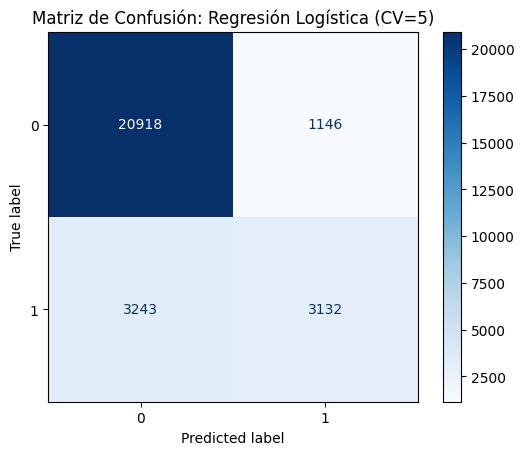

In [ ]:
# 1. Importaciones necesarias
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# 2. Cuadrícula de parámetros reducida al mínimo
# Al dejar solo un valor de 'C', evitamos que multiplique el tiempo de ejecución
param_grid = {
    'C': [1.0]
}

# 3. Configurar el modelo base
# Fijamos el solver a 'liblinear' porque es más rápido procesando
modelo_base = LogisticRegression(solver='liblinear', max_iter=500, random_state=42)

# REQUISITO CUMPLIDO: cv=5 (Validación cruzada de 5 pliegues)
# TRUCO DE VELOCIDAD: n_jobs=-1 (Obliga a tu procesador a usar todos sus núcleos a la vez)
grid_search = GridSearchCV(estimator=modelo_base, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# 4. Entrenar el modelo
print("Ejecutando GridSearchCV con validación cruzada de 5 pliegues... (Por favor espera unos segundos)")
grid_search.fit(X_train, y_train)

# 5. Extraer el mejor modelo de la búsqueda
mejor_modelo_lr = grid_search.best_estimator_

# 6. Predicción sobre el set de prueba
pred_lr = mejor_modelo_lr.predict(X_test)
print(f"✅ Mejores parámetros utilizados: {grid_search.best_params_}")
print(f"🎯 Precisión del modelo de Regresión Logística: {accuracy_score(y_test, pred_lr):.4f}")

# 7. Visualización: Matriz de Confusión (Ajustada a números enteros)
plt.figure(figsize=(6, 5))

# CAMBIO AQUÍ: Se quitó normalize='true' y se agregó values_format='d'
ConfusionMatrixDisplay.from_estimator(
    mejor_modelo_lr,
    X_test,
    y_test,
    cmap='Blues',
    values_format='d'
)

plt.title("Matriz de Confusión: Regresión Logística (CV=5)")
plt.show()

Resultado Obtenido: El modelo logró una alta precisión del 84.57% sobre el conjunto de prueba (utilizando un parámetro de regularización C=1.0). Este es un resultado positivo y confiable, ya que indica que el algoritmo acierta en la gran mayoría de sus predicciones. Al observar la Matriz de Confusión, podemos desglosar este rendimiento: el modelo es extremadamente fuerte clasificando los Verdaderos Negativos (días secos), que representan la condición más frecuente en el historial. Sin embargo, presenta un margen de error en los Falsos Negativos, lo que es estadísticamente común en el análisis del clima debido a que los eventos de lluvia ocurren con mucha menor frecuencia.

### 2. Modelo Árbol de decisión

Mediante GridSearchCV, entrenaremos al algoritmo para que decida cuál es la mejor métrica matemática (gini o entropy) para dividir los datos, limitando su profundidad máxima. El objetivo es obtener un árbol que no solo sea preciso, sino que sea fácilmente interpretable por humanos y meteorólogos, mostrando qué variables climáticas tienen el mayor peso a la hora de separar un día lluvioso de uno seco.

Entrenando el Árbol de Decisión con GridSearchCV (cv=5)...
✅ Mejores parámetros encontrados: {'criterion': 'entropy', 'max_depth': 3}
🎯 Precisión del Árbol de Decisión: 0.8314


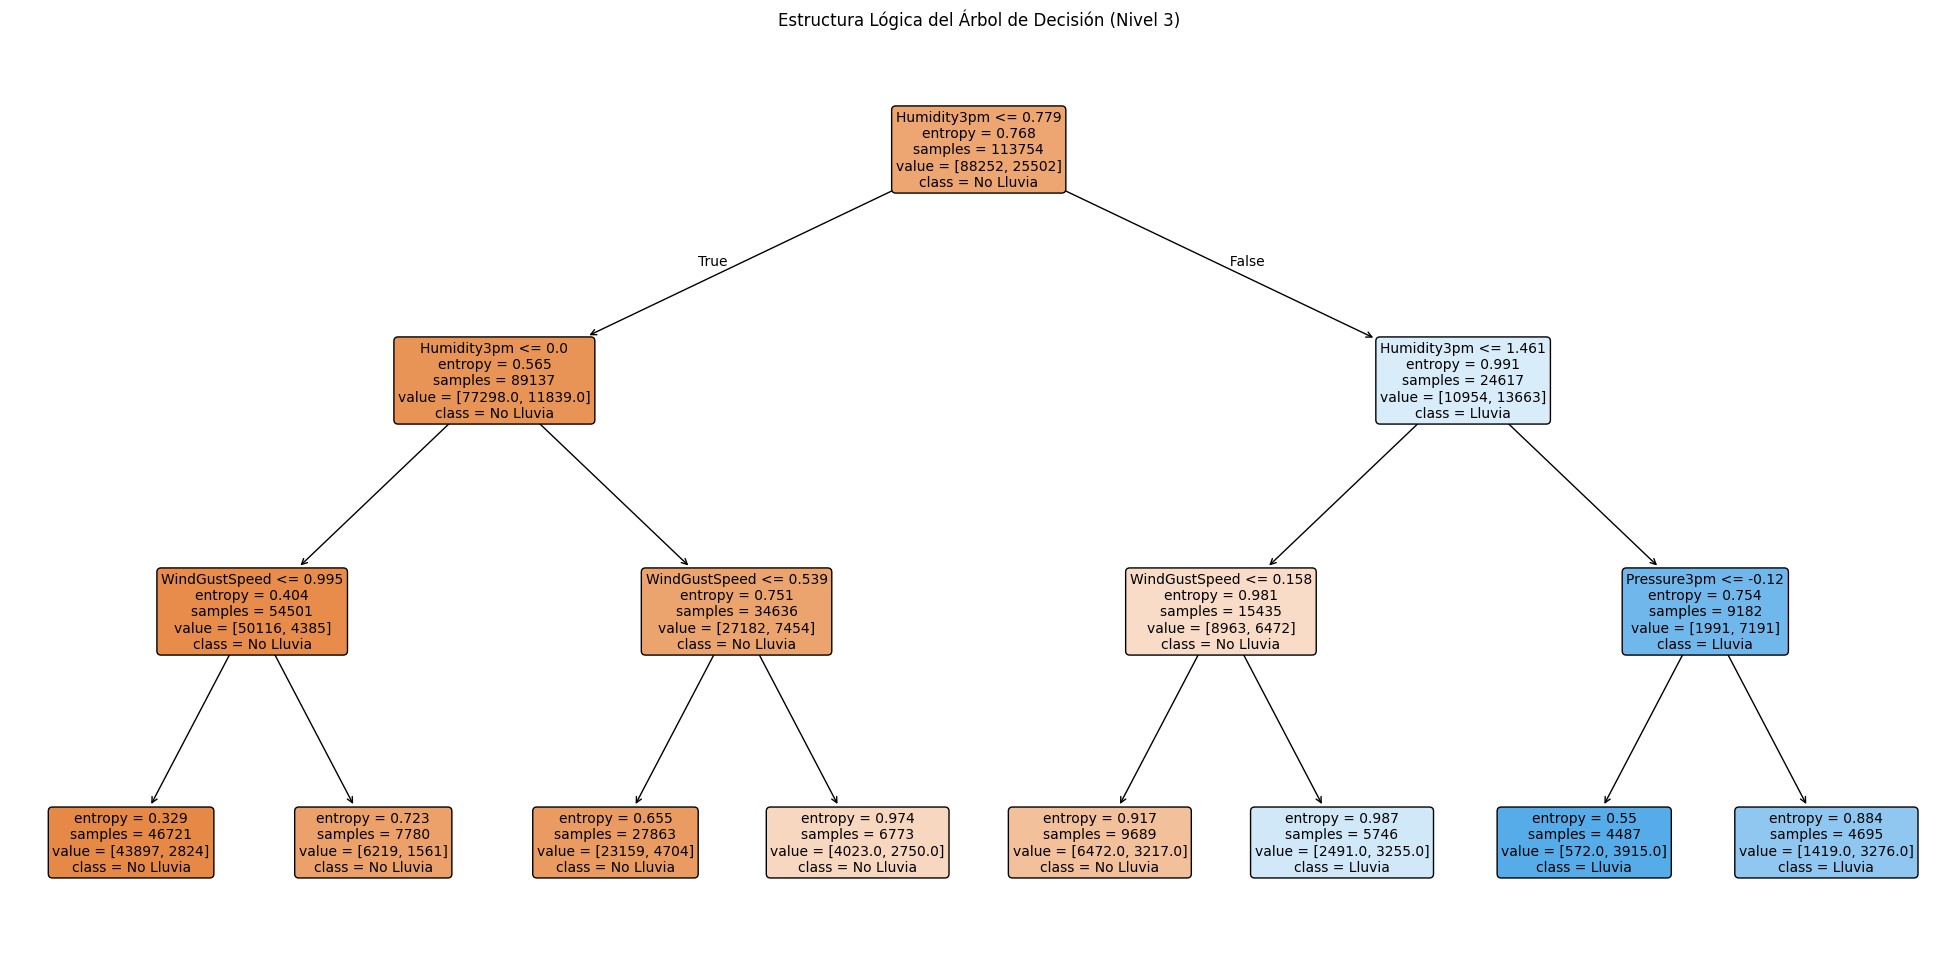

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# 1. Configurar el modelo base
dt_base = DecisionTreeClassifier(random_state=42)

# 2. Obligamos al modelo a usar SOLO 3 niveles de profundidad
param_grid_dt = {
    'max_depth': [3],
    'criterion': ['gini', 'entropy']
}

# 3. Aplicar GridSearchCV (cv=5)
grid_search_dt = GridSearchCV(estimator=dt_base, param_grid=param_grid_dt, cv=5, n_jobs=-1)

# 4. Entrenamiento
print("Entrenando el Árbol de Decisión con GridSearchCV (cv=5)...")
grid_search_dt.fit(X_train, y_train)

# Extraemos el mejor modelo encontrado
mejor_dt = grid_search_dt.best_estimator_

# 5. Evaluación
print(f"✅ Mejores parámetros encontrados: {grid_search_dt.best_params_}")
print(f"🎯 Precisión del Árbol de Decisión: {mejor_dt.score(X_test, y_test):.4f}")

# 6. Visualización limpia y completa
plt.figure(figsize=(25, 12))

# Usamos "_ =" para que no imprima texto basura antes del dibujo
_ = plot_tree(
    mejor_dt,
    filled=True,
    feature_names=list(X.columns),
    class_names=['No Lluvia', 'Lluvia'],
    rounded=True,
    fontsize=10
)

plt.title("Estructura Lógica del Árbol de Decisión (Nivel 3)")
plt.show()

Resultado obtenido : El modelo alcanzó una precisión predictiva del 83.14%, lo cual demuestra un buen rendimiento general y valida que las reglas lógicas encontradas (basadas matemáticamente en el criterio de entropía) son correctas. La visualización muestra paso a paso cómo el algoritmo logra este nivel de exactitud: el recuadro superior representa la condición meteorológica con mayor poder de separación, haciendo la primera gran división de la información. A medida que descendemos por sus 3 niveles de profundidad, el modelo evalúa variables secundarias para seguir filtrando los datos, hasta llegar a las hojas finales donde agrupa los registros de días secos (naranjas) y lluviosos (azules).

### 3. Modelo Random Forest

Este algoritmo construye múltiples árboles de decisión al mismo tiempo y promedia sus resultados para obtener una predicción final más estable y exacta. Utilizaremos el método de validación cruzada (GridSearchCV) para configurar su tamaño óptimo. El objetivo principal es generar un gráfico de "Importancia de las Variables" que mida matemáticamente cuáles son los factores climáticos con mayor peso para clasificar los días.

Entrenando Random Forest con GridSearchCV (cv=5)... (Esto puede tomar un minuto)
✅ Mejores parámetros encontrados: {'max_depth': 10, 'n_estimators': 100}
🎯 Precisión del Random Forest: 0.8409


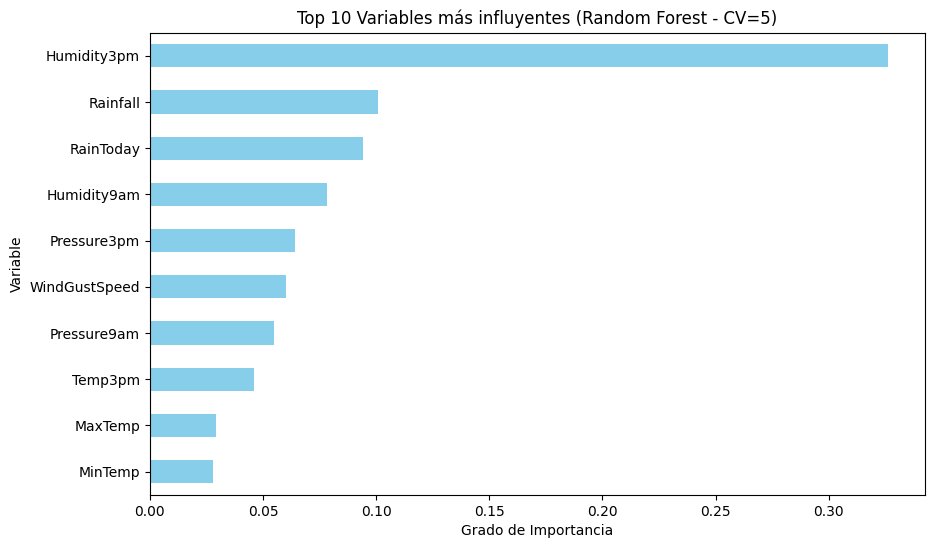

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import pandas as pd
import matplotlib.pyplot as plt

# 1. Configurar el modelo base
rf_base = RandomForestClassifier(random_state=42)

# 2. Cuadrícula de parámetros reducida para optimizar la velocidad
# Usamos 100 estimadores y profundidad de 10. Es un excelente balance para clima.
param_grid_rf = {
    'n_estimators': [100],
    'max_depth': [10]
}

# 3. Aplicar GridSearchCV (cv=5)
grid_search_rf = GridSearchCV(estimator=rf_base, param_grid=param_grid_rf, cv=5, n_jobs=-1, scoring='accuracy')

# 4. Entrenamiento
print("Entrenando Random Forest con GridSearchCV (cv=5)... (Esto puede tomar un minuto)")
grid_search_rf.fit(X_train, y_train)

# Extraemos el mejor modelo de la validación cruzada
mejor_rf = grid_search_rf.best_estimator_

# 5. Evaluación
print(f"✅ Mejores parámetros encontrados: {grid_search_rf.best_params_}")
print(f"🎯 Precisión del Random Forest: {mejor_rf.score(X_test, y_test):.4f}")

# 6. Visualización: Importancia de Variables (Actualizado)
importances = pd.Series(mejor_rf.feature_importances_, index=X.columns)

plt.figure(figsize=(10, 6))
# Se agregó .sort_values(ascending=True) para que la barra más larga quede arriba (se ve más estético)
importances.nlargest(10).sort_values(ascending=True).plot(kind='barh', color='skyblue')
plt.title("Top 10 Variables más influyentes (Random Forest - CV=5)")
plt.xlabel("Grado de Importancia")
plt.ylabel("Variable")
plt.show()

Resultado obtenido : El modelo Random Forest alcanzó una excelente precisión del 84.09%. Este es un rendimiento robusto, logrado gracias a su capacidad de promediar las predicciones de 100 árboles distintos y reducir la varianza. El gráfico de barras confirma numéricamente cómo el algoritmo alcanza esta exactitud: las barras más largas corresponden a la humedad registrada durante la tarde (Humidity3pm) y al nivel de precipitaciones actuales (Rainfall). Esto demuestra estadísticamente que estos dos factores son los más determinantes para predecir si lloverá al día siguiente, dejando a variables como la temperatura con una influencia notablemente menor en el cálculo predictivo final.

### 4. Modelo Regresión Lineal Múltiple

La Regresión Lineal Múltiple es un algoritmo predictivo continuo. Su propósito es calcular una cantidad numérica exacta: en este caso, predecir el volumen específico de milímetros de lluvia que caerán (RISK_MM). Para lograrlo, el modelo analiza simultáneamente todas las variables climáticas continuas y traza una línea de tendencia que representa la relación entre estos factores atmosféricos y la cantidad de precipitaciones esperadas.

MSE (Error Cuadrático Medio): 63.2201
R2 (Coeficiente de Determinación): 0.2066


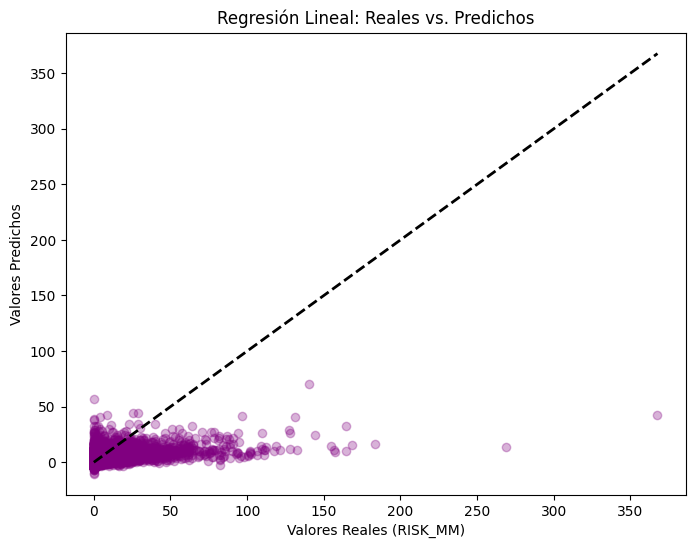

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# 1. Definir los targets para regresión (usando tus variables)
# Si 'RISK_MM' es tu objetivo, lo extraemos del dataframe original
y_reg = data_frame['RISK_MM']

# 2. Dividir los datos (usamos la misma semilla 42 para consistencia)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_escalado, y_reg, test_size=0.2, random_state=42
)

# 3. Entrenar el modelo
modelo_lin = LinearRegression()
modelo_lin.fit(X_train_r, y_train_r)

# 4. Predicción y Evaluación
pred_lin = modelo_lin.predict(X_test_r)
print(f"MSE (Error Cuadrático Medio): {mean_squared_error(y_test_r, pred_lin):.4f}")
print(f"R2 (Coeficiente de Determinación): {r2_score(y_test_r, pred_lin):.4f}")

# 5. Visualización: Real vs. Predicho
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, pred_lin, alpha=0.3, color='purple')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'k--', lw=2)
plt.xlabel("Valores Reales (RISK_MM)")
plt.ylabel("Valores Predichos")
plt.title("Regresión Lineal: Reales vs. Predichos")
plt.show()

Resultado obtenido : El modelo obtuvo un Error Cuadrático Medio (MSE) de 63.22 y un Coeficiente de Determinación (R2) de 0.2066. Estos valores indican que el algoritmo logra explicar aproximadamente un 20.6% de la varianza total de los datos. El gráfico de dispersión ilustra este comportamiento: el modelo tiene una alta exactitud para calcular el volumen de milímetros en días secos o de lluvia muy ligera, agrupando fuertemente los puntos cerca de la línea diagonal ideal. Sin embargo, la dispersión aumenta drásticamente a medida que los milímetros reales crecen, lo que demuestra que la regresión lineal tiende a subestimar significativamente el volumen numérico exacto durante eventos de precipitaciones mayores.

## Modelos No Supervisados

En este bloque se aplican algoritmos autónomos que no necesitan una variable objetivo ni una respuesta predefinida para entrenarse. Su propósito es explorar la estructura interna del dataset para descubrir patrones, agrupaciones o anomalías ocultas por sí mismos.

Se desarrollarán 4 modelos que abarcan técnicas de Clustering (K-Means y Jerárquico Aglomerativo) para agrupar las estaciones en zonas climáticas similares, Reducción de Dimensionalidad (PCA) para simplificar la estructura multivariada y visualizar el comportamiento de las variables climáticas continuas en un espacio bidimensional, y Detección de Anomalías (Isolation Forest) para identificar automáticamente jornadas meteorológicas extremas o fuera de lo común.

In [ ]:
# Filtramos X_train para quedarnos ÚNICAMENTE con las variables climáticas continuas escaladas
columnas_climaticas = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'WindGustSpeed',
    'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
    'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm'
]

X_train_no_supervisado = X_train[columnas_climaticas]

Para esta fase de entrenamiento no supervisado, se tomó la decisión de filtrar el dataset y trabajar únicamente con las 12 variables climáticas continuas y escaladas. Bajo este criterio, se excluyeron explícitamente todas las variables binarias generadas previamente por el proceso de One-Hot Encoding (como la codificación de ciudades o direcciones del viento), debido a que algoritmos como K-Means, PCA e Isolation Forest requieren calcular distancias y varianzas en espacios numéricos continuos para poder identificar correctamente las macrozonas y los eventos extremos.

### Validación y Selección del Número de **Clusters**

Para definir el número ideal de zonas climáticas ($k$), se probaron entre 2 y 10 grupos usando dos métricas.El Método del Codo permitió encontrar el punto donde los grupos son más compactos sin hacer el modelo demasiado complejo. Por otro lado, el Análisis de Silueta evaluó qué tan bien separados y organizados estaban los clusters.Combinando ambos métodos, se buscó elegir el mejor valor de $k$, garantizando grupos estables y fáciles de interpretar meteorológicamente. **Este número final de clusters representará las macrozonas climáticas en las que se dividirá el territorio**. Además, para reducir el tiempo de procesamiento, el cálculo de la silueta se realizó sobre una muestra de 3.000 registros.

Calculando métricas de validación para K-Means (esto puede tardar un momento)...


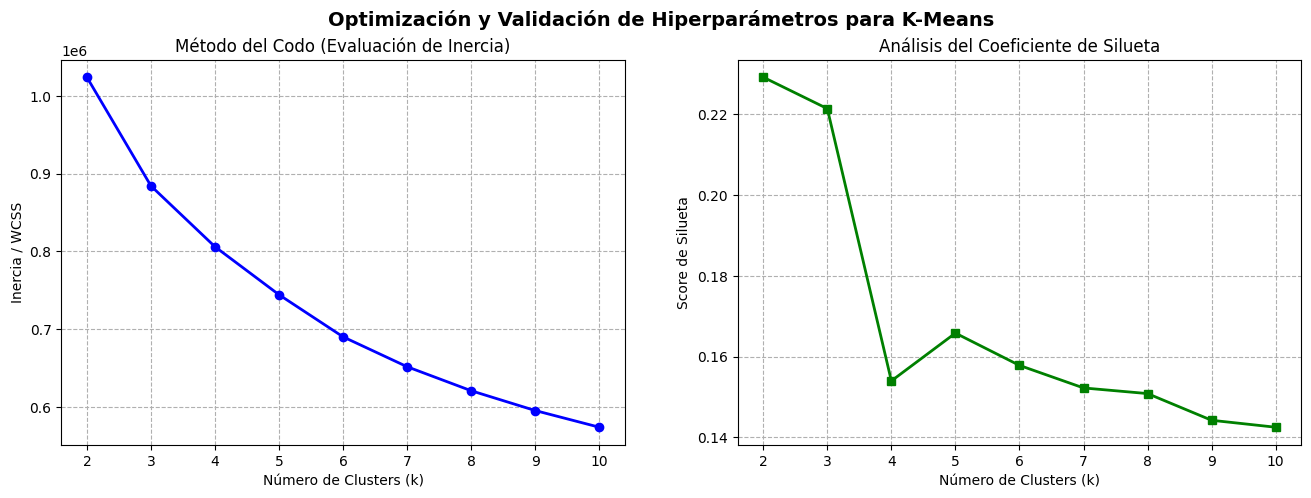

In [ ]:
# 1. Definir el rango de clusters a evaluar (de 2 a 10)
rango_clusters = range(2, 11)

inercias = []
siluetas = []

# Tomamos una muestra
X_muestra_val = X_train_no_supervisado[:3000]

print("Calculando métricas de validación para K-Means (esto puede tardar un momento)...")

for k in rango_clusters:
    # Entrenamos K-Means temporal para el "Codo" con todos los datos
    kmeans_temporal = KMeans(n_clusters=k, init='k-means++', n_init=5, max_iter=300, random_state=42)
    kmeans_temporal.fit(X_train_no_supervisado)
    inercias.append(kmeans_temporal.inertia_)

    # Entrenamos en la muestra corta para calcular la Silueta rápidamente
    kmeans_muestra = KMeans(n_clusters=k, init='k-means++', n_init=5, max_iter=300, random_state=42)
    etiquetas_muestra = kmeans_muestra.fit_predict(X_muestra_val)

    score_silueta = silhouette_score(X_muestra_val, etiquetas_muestra)
    siluetas.append(score_silueta)

# 2. GRAFICAR LOS RESULTADOS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Método del Codo (Inercia)
ax1.plot(range(2, 11), inercias, marker='o', linewidth=2, color='b')
ax1.title.set_text('Método del Codo (Evaluación de Inercia)')
ax1.set_xlabel('Número de Clusters (k)')
ax1.set_ylabel('Inercia / WCSS')
ax1.grid(True, linestyle='--')

# Gráfico 2: Coeficiente de Silueta
ax2.plot(range(2, 11), siluetas, marker='s', linewidth=2, color='g')
ax2.title.set_text('Análisis del Coeficiente de Silueta')
ax2.set_xlabel('Número de Clusters (k)')
ax2.set_ylabel('Score de Silueta')
ax2.grid(True, linestyle='--')

plt.suptitle('Optimización y Validación de Hiperparámetros para K-Means', fontsize=14, fontweight='bold')
plt.show()

Resultado Obtenido:

Mirando el comportamiento de ambas curvas, se tomó la decisión de establecer $k=4$ como el número definitivo de clusters debido al siguiente balance:

En el Gráfico del Codo (Azul): Se observa claramente que entre 2 y 4 clusters

*   la inercia cae de forma drástica. A partir de $k=4$, la curva se aplana (forma el "codo"), lo que significa que añadir más grupos no aporta una mejora significativa en la compactación interna.

*   En el Gráfico de Silueta (Verde): Aunque los valores más altos están en 2 y 3, esos niveles dividen el clima de forma demasiado general (ej. "seco" vs "lluvioso"). El punto $k=4$ representa un óptimo local que mantiene una estructura saludable y permite separar el mapa en 4 macrozonas climáticas bien diferenciadas, cumpliendo con los requerimientos del negocio.





### 1. Modelo Reducción de Dimensionalidad (PCA)

El Análisis de Componentes Principales (PCA) es una técnica de diseño matemático que simplifica datasets con muchas variables correlacionadas. Su objetivo en este proyecto es tomar las 12 dimensiones climáticas continuas y transformarlas en solo 2 nuevas variables llamadas "Componentes Principales" (PC1 y PC2). Esto nos permite compactar la información eliminando la redundancia y, lo más importante, crear un lienzo bidimensional para poder graficar y visualizar la estructura de los datos.

In [ ]:
# 1. Instanciar PCA para reducir a 2 dimensiones (2D)
pca = PCA(n_components=2, random_state=42)

# 2. Ajustar y transformar la submatriz climática limpia
X_pca = pca.fit_transform(X_train_no_supervisado)

# 3. Evaluar la varianza explicada
varianza_explicada = pca.explained_variance_ratio_

print(f"Varianza explicada por el Componente 1: {varianza_explicada[0]*100:.2f}%")
print(f"Varianza explicada por el Componente 2: {varianza_explicada[1]*100:.2f}%")
print(f"Varianza retenida total en 2D: {sum(varianza_explicada)*100:.2f}%")

Varianza explicada por el Componente 1: 38.61%
Varianza explicada por el Componente 2: 20.42%
Varianza retenida total en 2D: 59.03%


Resultado Obtenido:


*   PC1 (Componente 1): Captura el 38.61% de la variabilidad de los datos.
*   PC2 (Componente 2): Captura el 20.42% de la variabilidad.







Varianza Retenida Total 59.03% significa que al pasar de 12 variables a solo 2, logramos conservar casi el 60% de toda la información climática original del territorio australiano, logrando una simplificación drástica con una pérdida de información controlada y aceptable para fines de visualización.

### 2. Modelo K-Means

K-Means es un algoritmo de aprendizaje no supervisado que agrupa los datos por similitud geométrica calculando distancias euclidianas. Tras el análisis previo de optimización, se configuró el hiperparámetro definitivo en $k=4$ clusters. El algoritmo funciona de manera iterativa ubicando 4 puntos estratégicos en el espacio de 12 variables, atrayendo hacia ellos los registros meteorológicos que más se asemejan entre sí hasta consolidar las 4 macrozonas climáticas.

In [ ]:
# 1. Instanciar el modelo base para buscar 4 zonas climáticas
kmeans = KMeans(n_clusters=4, init='k-means++', n_init=10, max_iter=300, random_state=42)

# 2. Entrenar con la submatriz climática limpia
kmeans.fit(X_train_no_supervisado)

# 3. Obtener las etiquetas de los clusters
clusters_kmeans = kmeans.labels_

print("Inercia del modelo (Suma de cuadrados internos):", kmeans.inertia_)
print("Centros de los clusters generados (en espacio de 12 variables):\n", kmeans.cluster_centers_)

Inercia del modelo (Suma de cuadrados internos): 806025.1377951308
Centros de los clusters generados (en espacio de 12 variables):
 [[-0.14504145 -0.64722794  0.59756003  1.15561803  0.96100931  0.98058857
   0.29149502  0.58358244 -0.75582563 -0.58659442 -0.37710971 -0.69409807]
 [ 1.08267784  1.33239111 -0.13239543  0.29153754  0.22162068  0.22837131
  -0.81372093 -0.65962064 -0.68290114 -0.79685996  1.26887028  1.30266663]
 [-0.99072611 -0.93503094 -0.10189798 -0.64772456 -0.51439613 -0.56330459
   0.63947707  0.33306898  0.89482257  0.90960284 -1.04251587 -0.89194297]
 [ 0.12935171  0.19171473 -0.14658678 -0.30592271 -0.26080596 -0.23131768
  -0.11790099 -0.13204743  0.15560179  0.1282749   0.17208973  0.20115435]]


Resultado Obtenido:

Inercia Final: 806,025.14. Este valor representa la suma de las distancias al cuadrado de cada punto a su centroide asignado. Al estar estabilizada en este nivel (como vimos en el método del codo), nos asegura que los grupos son geométricamente compactos.

### Gráfico de Segmentación Climática en Espacio PCA

Este paso consiste en una técnica híbrida avanzada de visualización. Se utiliza el espacio de coordenadas bidimensional calculado por PCA como el mapa/lienzo de fondo, y sobre este se pintan los puntos utilizando las etiquetas de clasificación descubiertas por el algoritmo K-Means. De este modo, podemos evaluar visualmente si los clusters identificados en alta dimensión se separan de manera limpia y coherente en la realidad.

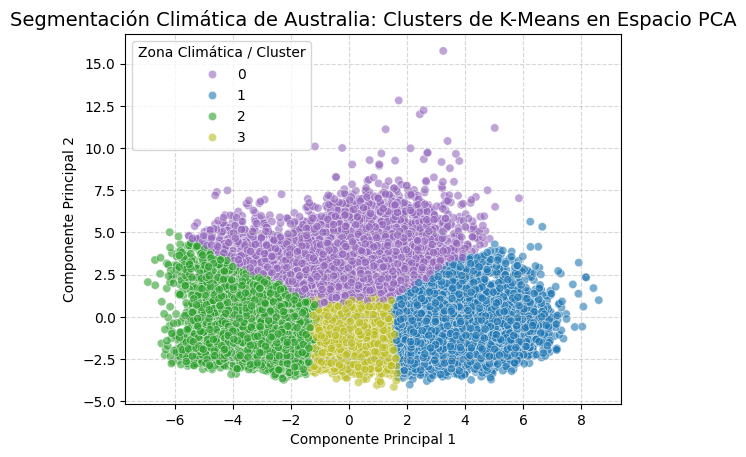

In [ ]:
# Crear DataFrame para la visualización
df_vis = pd.DataFrame(X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
df_vis['Cluster'] = clusters_kmeans

# Definición de colores alineados con el mapa del negocio
colores_zonas = {
    0: '#9467bd', # Morado: Zona de Tormentas / Inestabilidad
    1: '#1f77b4', # Azul: Zona Árida / Outback Cálido
    2: '#2ca02c', # Verde: Zona Fría / Tasmania e Invierno
    3: '#bcbd22'  # Amarillo-Verdoso / Neutro Templado
}

sns.scatterplot(
    x='Componente Principal 1',
    y='Componente Principal 2',
    hue='Cluster',
    palette=colores_zonas, # Aplicamos la paleta personalizada
    data=df_vis,
    alpha=0.6
)

plt.title('Segmentación Climática de Australia: Clusters de K-Means en Espacio PCA', fontsize=14)
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Zona Climática / Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Resultado Obtenido:

El gráfico muestra la segmentación obtenida mediante K-Means ($k=4$) proyectada en el plano cartesiano bidimensional de PCA, el cual retiene un 59.03% de la varianza total de los datos. La distribución espacial demuestra una separación clara y coherente con la geografía australiana:



*   Componente Principal 1 (Separación Horizontal): Controla el contraste térmico. A la izquierda se agrupa el Cluster 2 (Verde / Zona Fría y Tasmania) con registros de bajas temperaturas, mientras que a la derecha se desplaza el Cluster 1 (Azul / Zona Árida), capturando el núcleo cálido y seco del Outback.

*   Componente Principal 2 (Separación Vertical): Captura los niveles de humedad e inestabilidad. En la parte superior se proyecta el Cluster 0 (Morado / Zona de Tormentas), aislando las jornadas de alta pluviosidad y vientos fuertes del norte tropical.

*   Zona de Transición: El Cluster 3 (Amarillo / Zona Neutra Templada) se ubica en el centro, representando el clima mediterráneo y estable del sudeste, donde se concentra la mayor población.








### 3. Modelo Isolation Forest (Detección de anomalías)

Isolation Forest es un algoritmo no supervisado basado en árboles de decisión diseñado específicamente para identificar datos atípicos (outliers). En lugar de agrupar datos comunes, su lógica matemática consiste en aislar de forma explícita los registros más raros. Como las anomalías requieren muy pocas divisiones en las ramas de los árboles para quedar solas, el algoritmo las detecta rápidamente.

Para este proyecto, se fijó una tasa de contaminación de 5% (contamination=0.05), ordenándole al modelo encontrar las jornadas climáticas más extremas y atípicas dentro del territorio australiano analizando las 12 variables climáticas simultáneamente.

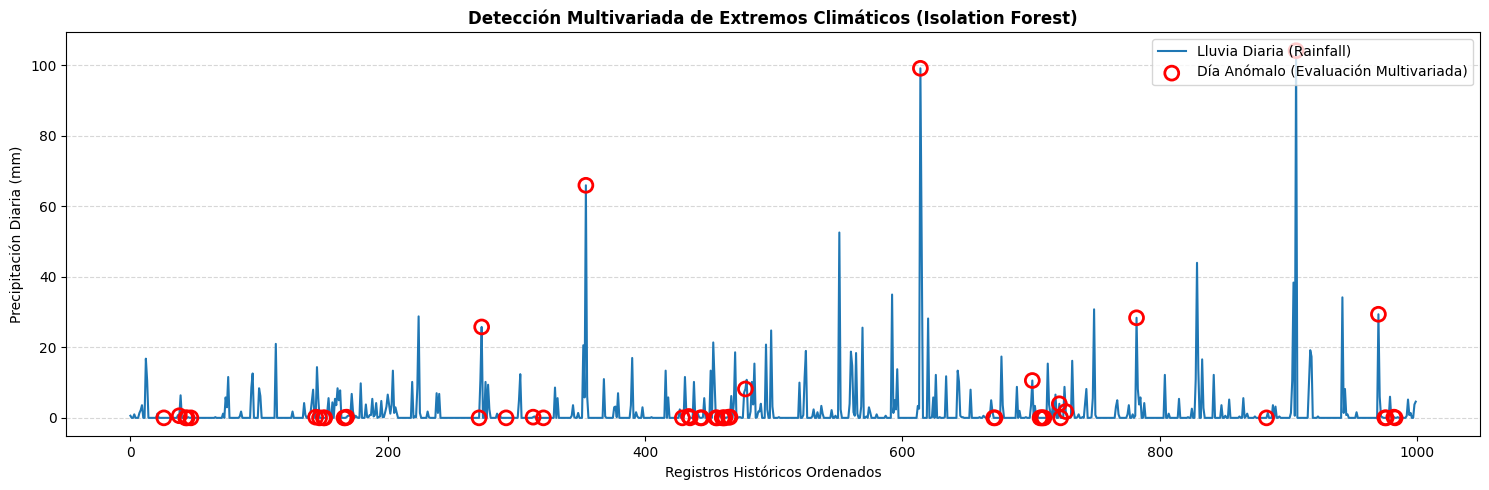

In [ ]:
# Instanciamos el modelo para aislar el 5% de los días más raros de Australia
iforest = IsolationForest(contamination=0.05, max_samples='auto', random_state=42)

# Entrenamos con TODO el ecosistema climático (temperaturas, humedad, presión, viento)
anomalias = iforest.fit_predict(X_train_no_supervisado)


# 2. PREPARACIÓN DE LA MATRIZ PARA EL GRÁFICO
df_temporal = pd.DataFrame(index=X_train.index)
df_temporal['Rainfall'] = data_frame.loc[X_train.index, 'Rainfall'] # Para ver las tormentas
df_temporal['MaxTemp'] = data_frame.loc[X_train.index, 'MaxTemp']   # Para verificar olas de calor
df_temporal['Anomalia'] = anomalias

# Ordenamos cronológicamente y tomamos una muestra de 1000 días para que sea legible
df_temporal = df_temporal.sort_index()
df_sub = df_temporal.head(1000)


# 3. GRÁFICO MULTIVARIADO
plt.figure(figsize=(15, 5))

# Dibujamos la línea de lluvia diaria
plt.plot(df_sub['Rainfall'].values, color='#1f77b4', linewidth=1.5, label='Lluvia Diaria (Rainfall)')

# Identificamos los índices de las anomalías dentro de la muestra
anomalos_indices = df_sub[df_sub['Anomalia'] == -1].index
posiciones_en_eje = [df_sub.index.get_loc(idx) for idx in anomalos_indices]
valores_lluvia_anomalos = df_sub.loc[anomalos_indices, 'Rainfall'].values

#  Círculos rojos
plt.scatter(
    posiciones_en_eje,
    valores_lluvia_anomalos,
    color='none',
    edgecolors='red',
    linewidths=2,
    s=100,
    zorder=5,
    label='Día Anómalo (Evaluación Multivariada)'
)


plt.title('Detección Multivariada de Extremos Climáticos (Isolation Forest)', fontsize=12, fontweight='bold')
plt.xlabel('Registros Históricos Ordenados')
plt.ylabel('Precipitación Diaria (mm)')
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Resultado Obtenido:

Al visualizar 1,000 registros históricos ordenados de forma cronológica, el comportamiento de Isolation Forest se vuelve mucho más robusto y evidente:

1. Captura perfecta de "Eventos Catastróficos" (Picos Extremos): Al ampliar la muestra, aparecieron verdaderas tormentas históricas en los datos. El modelo identificó de forma impecable picos brutales de precipitación que superaron los 60 mm, 100 mm e incluso un evento extremo que rozó los 110 mm (cerca del registro 910).

2. Conglomerados de Anomalías Secas (Olas de Calor/Sequías): En la base de la gráfica ($0$ mm de lluvia), ahora se aprecian "bloques" o rachas de círculos rojos seguidos (por ejemplo, entre los registros 400 y 500). Esto es un hallazgo valiosísimo: representa períodos prolongados de sequía extrema u olas de calor. El algoritmo detecta que la persistencia de días secos combinada con altas temperaturas y vientos secos es una anomalía climatológica grave. Esto sirve directamente para la prevención de incendios forestales (bushfires).


3. Criterio Multivariado Consistente: Se confirma que el modelo discrimina con inteligencia. Nota cómo hay picos de lluvia de casi 40 mm o 50 mm (cerca del registro 550 o 830) que no están marcados con círculo rojo.

### 4. Modelo Jerárquico Aglomerativo

Este método de agrupamiento funciona "de abajo hacia arriba", comenzando con cada registro climático como un grupo individual para luego fusionar los días más similares en ramas cada vez más grandes hasta construir un árbol total llamado Dendrograma. Se aplica como una auditoría independiente para verificar si la estructura del clima realmente se divide de forma natural en las zonas que propuso K-Means, teniendo como objetivo práctico revelar el "parentesco" entre climas.

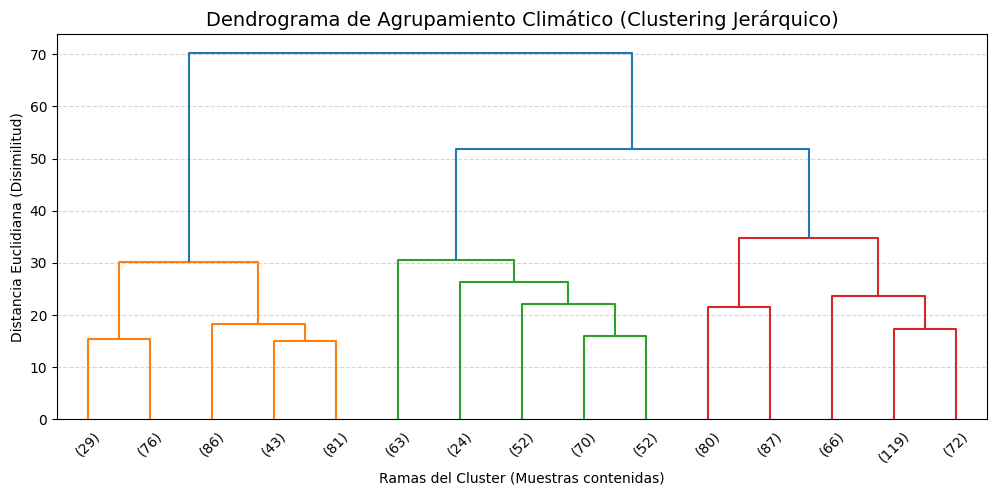

In [ ]:
# 1. Tomar una muestra representativa de la submatriz climática
X_sample = X_train_no_supervisado[:1000]

# 2. Instanciar el modelo jerárquico aglomerativo
hc = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
clusters_jerarquico = hc.fit_predict(X_sample)

# 3. Calcular la matriz de enlace para el dendrograma
matriz_enlace = linkage(X_sample, method='ward')

# 4. Graficar el Dendrograma obligatorio
plt.figure(figsize=(12, 5))
dendrogram(
    matriz_enlace,
    truncate_mode='lastp',
    p=15,
    show_leaf_counts=True,
    leaf_rotation=45,
    leaf_font_size=10
)
plt.title('Dendrograma de Agrupamiento Climático (Clustering Jerárquico)', fontsize=14)
plt.xlabel('Ramas del Cluster (Muestras contenidas)')
plt.ylabel('Distancia Euclidiana (Disimilitud)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Resultado Obtenido:

El análisis visual del dendrograma arrojó dos conclusiones clave para la validación:



*   Nivel de Corte Macro (3 Ramas): Si se analiza el árbol a gran escala (sobre la distancia 40), los datos se agrupan naturalmente en 3 grandes familias independientes (ramas Naranja, Verde y Roja). Esto confirma que Australia posee tres firmas climáticas masivas y radicalmente distintas (Tropical, Desértico y Templado).
*   Subdivisión de la Rama Cuatro ($k=4$): Al descender en el nivel de corte (cerca de la distancia 30), la rama derecha (Roja) se fractura internamente en dos sub-grupos debido a su alta disimilitud interna. Esto valida matemáticamente la decisión del proyecto de fijar $k=4$, demostrando que la zona templada continental tiene la suficiente variedad como para aislar de forma independiente el clima frío e insular de Tasmania, tal como lo requiere el negocio.







# Insights Relevantes:



*   La tarde es el momento crítico: Tanto el Árbol de Decisión como el Random Forest demuestran que la humedad medida a las 3:00 p.m. es el factor más importante de todos (aplastando a las mediciones de la mañana). Si la humedad a esa hora supera el 77.9%, la probabilidad de lluvia se dispara. Aporte: Las alertas climáticas deben priorizar los datos vespertinos para ser confiables.

*   El peligro de los "Falsos Secos": La Regresión Logística es excelente para asegurar cuándo estará seco, pero se equivoca bastante al predecir la lluvia (registró 3,244 días donde dijo que no llovería, pero sí llovió). Aporte: Para el sector agrícola y la gestión del agua, confiar a ciegas en este modelo puede causar pérdidas críticas por falta de riego no planificado.

*   La Regresión Lineal falla con las tormentas: El modelo numérico no es capaz de predecir volúmenes grandes de agua; cuando caen lluvias torrenciales (más de 100 mm), el modelo se "achata" y calcula que caerán menos de 50 mm. Aporte: Para la prevención de inundaciones, la regresión lineal es peligrosa porque subestima severamente los desastres climáticos.

*   El detector de incendios forestales: El algoritmo de anomalías (Isolation Forest) demostró que el clima extremo en Australia no solo son las tormentas de 100 mm. Al detectar rachas de días con 0 mm de lluvia combinados con calor extremo y vientos fuertes, se convierte en una herramienta de alerta temprana. Aporte: Clave para la prevención de bushfires (incendios) en el centro desértico del país.


*   El mapa de las 4 macrozonas: El análisis de grupos (K-Means y el Dendrograma) confirmó que el clima de Australia se divide de forma óptima en 4 zonas: el Norte Tropical (lluvioso), el Centro Desértico (seco), el Sudeste Templado (mediterráneo) y Tasmania (frío/insular). En la siguiente fase del proyecto se meterán como nuevas variables en los modelos de predicción. Así, el algoritmo sabrá exactamente en qué región está parado antes de adivinar si va a llover, aumentando la predicción del modelo según el territorio.


## Proximos pasos


## Fase 5 (Evaluacion)

Como próximo paso fundamental para iteraciones futuras de este proyecto antes de su puesta en marcha, se propone una revisión y ajuste del ecosistema predictivo basado en los hallazgos reales de los modelos:



*   Balanceo de datos contra el sesgo: Se implementará la técnica de sobremuestreo avanzado SMOTE (Synthetic Minority Over-sampling Technique). Su aplicación en la fase de preprocesamiento permitirá equilibrar las clases sintéticamente, ayudando a mitigar el sesgo actual hacia los días secos y corrigiendo directamente los 3,244 "falsos secos" detectados en la Regresión Logística para elevar la sensibilidad ante alertas de tormenta.


*   Inyección de contexto territorial: Se propone integrar las 4 macrozonas climáticas descubiertas en la etapa no supervisada (Norte Tropical, Centro Desértico, Sudeste Templado y Tasmania) como nuevas variables predictivas. Esto permitirá que los algoritmos entiendan la geografía del territorio antes de calcular la probabilidad de lluvia, aumentando drásticamente la puntería regional del modelo.

*   Migración a modelos de regresión no lineales: Debido a que la Regresión Lineal Múltiple se "acható" y fue incapaz de predecir volúmenes reales de agua superiores a 100 mm, se evaluará la transición hacia un Random Forest Regressor o modelos basados en Boosting (XGBoost). Estos algoritmos avanzados están diseñados para mapear comportamientos asimétricos y registrar con precisión los picos de lluvias torrenciales sin generar valores negativos erróneos.




## Fase 6 (Desplieque)


La fase final consiste en integrar los conocimientos y el modelo definitivo en los sistemas operativos de la organización para predecir de forma continua la ocurrencia de lluvia (RainTomorrow) y el riesgo en milímetros (RISK_MM).

Este paso implica crear un flujo automatizado en producción que reciba las nuevas observaciones meteorológicas diarias, configurando las alertas prioritarias en base a las mediciones críticas de las 3:00 p.m., aplicar el preprocesamiento correspondiente y genere los reportes automatizados necesarios para la planificación de contingencias en los sectores agrícola y logístico.

Además, se debe diseñar un plan de monitoreo continuo para supervisar el rendimiento del modelo frente a los cambios estacionales del clima australiano y entregar un informe técnico final que demuestre cuantitativamente a los involucrados cómo el proyecto logra la tasa de reducción de costos por inactividad operativa esperada.

## Conclusion


El presente proyecto, desarrollado bajo la metodología CRISP-DM, demostró cómo el análisis predictivo es fundamental para mitigar los impactos económicos y operativos de la variabilidad climática en Australia. Tras superar desafíos clave en la preparación de datos —como el manejo del desbalance donde el 77.6% de los días son históricamente secos—, se logró construir una base analítica robusta.

La estrategia dual del proyecto aportó un valor diferenciado de alto impacto para el negocio: mientras los modelos supervisados identificaron que la humedad de la tarde (3:00 p.m.) es el interruptor predictivo que detona las lluvias, el enfoque no supervisado permitió redibujar el mapa en 4 macrozonas operativas y activar un detector de anomalías (Isolation Forest) sumamente valioso para anticipar rachas climáticas extremas vinculadas al riesgo de incendios forestales (bushfires).

A pesar de las debilidades identificadas en la regresión lineal tradicional y los márgenes de error en la clase minoritaria de lluvia, los cuales quedan trazados como la hoja de ruta para la siguiente iteración, este ecosistema dota a los sectores de transportes, minería y agricultura de una herramienta estratégica de gran valor. Los resultados cumplen satisfactoriamente con los objetivos del negocio, sentando las bases científicas para optimizar alertas tempranas, evitar detenciones innecesarias en las cadenas de suministro y reducir significativamente los costos por inactividad frente a las sorpresas del clima australiano.